# **nalara.academy**

## **Modul 3 - AI & Machine Learning**
### **Sesi 3: Supervised Learning Beraksi & Evaluasi**

### **📌 Pengantar Sesi**
Di Sesi 2 kita sudah berhasil menerjemahkan ribuan gambar daun menjadi tabel fitur histogram
warna (`fitur_daun.csv`). Sekarang saatnya melatih AI untuk benar-benar **mengklasifikasikan**
daun sehat vs sakit menggunakan dua algoritma klasik: **KNN** dan **SVM** — lalu menilai
performanya secara jujur menggunakan **Confusion Matrix**, bukan hanya angka akurasi semata.

> ⚠️ **Catatan:** Notebook ini melanjutkan dari Sesi 2. Pastikan file `fitur_daun.csv` sudah
> ada di folder yang sama (hasil dari menjalankan notebook Sesi 2 terlebih dahulu).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

sns.set_style("whitegrid")
print("✅ Semua library berhasil diimpor.")

✅ Semua library berhasil diimpor.


## **📂 1. Memuat Data Fitur Hasil Sesi 2**

In [2]:
df_fitur = pd.read_csv("fitur_daun.csv")

print(f"📐 Ukuran data fitur: {df_fitur.shape[0]} baris, {df_fitur.shape[1]} kolom")
df_fitur.head()

📐 Ukuran data fitur: 8472 baris, 25 kolom


,hist_B_0,hist_B_1,hist_B_2,hist_B_3,hist_B_4,hist_B_5,hist_B_6,hist_B_7,hist_G_0,hist_G_1,...,hist_G_7,hist_R_0,hist_R_1,hist_R_2,hist_R_3,hist_R_4,hist_R_5,hist_R_6,hist_R_7,label
0,0.013389,0.571353,0.778036,0.260833,0.001190,0.000099,0.0,0.0,0.027383,0.672486,...,0.0,0.032074,0.822431,0.567608,0.019350,0.004948,0.001237,0.000000,0.000000,diseased
1,0.041500,0.616272,0.783570,0.065916,0.012533,0.001300,0.0,0.0,0.053423,0.740030,...,0.0,0.055269,0.883420,0.434925,0.154418,0.049525,0.026842,0.018324,0.000099,diseased
2,0.035612,0.603213,0.785081,0.136068,0.000095,0.000000,0.0,0.0,0.048846,0.649908,...,0.0,0.046562,0.742373,0.668054,0.020162,0.003436,0.000723,0.000000,0.000000,diseased
3,0.051006,0.746452,0.663443,0.007171,0.000627,0.000000,0.0,0.0,0.045913,0.804535,...,0.0,0.046312,0.916443,0.397379,0.008375,0.002512,0.001089,0.000000,0.000000,diseased
4,0.032944,0.596153,0.796701,0.093620,0.004374,0.000931,0.0,0.0,0.052526,0.697719,...,0.0,0.053912,0.784230,0.605104,0.125697,0.010821,0.002898,0.000290,0.000000,diseased


📊 Distribusi kelas pada data fitur:
label
healthy     4258
diseased    4214
Name: count, dtype: int64


C:\Users\Asus\AppData\Local\Temp\ipykernel_15136\1701975704.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_fitur, x="label", palette="Set2")


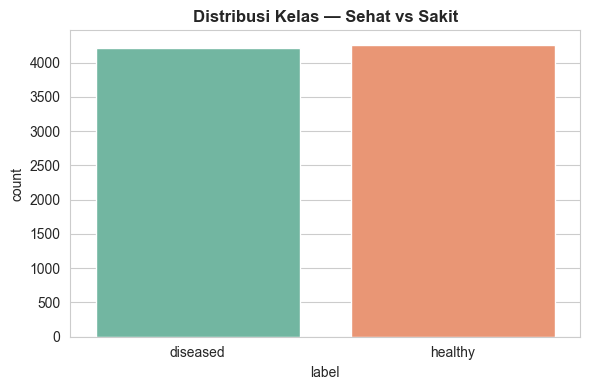

In [3]:
print("📊 Distribusi kelas pada data fitur:")
print(df_fitur["label"].value_counts())

plt.figure(figsize=(6, 4))
sns.countplot(data=df_fitur, x="label", palette="Set2")
plt.title("Distribusi Kelas — Sehat vs Sakit", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

## **🔤 2. Encoding Label & Split Data**

In [4]:
label_encoder = LabelEncoder()
df_fitur["label_encoded"] = label_encoder.fit_transform(df_fitur["label"])

print("🔤 Mapping label:")
for asli, angka in zip(label_encoder.classes_, range(len(label_encoder.classes_))):
    print(f"   {asli} -> {angka}")

X = df_fitur.drop(columns=["label", "label_encoded"])
y = df_fitur["label_encoded"]

print(f"\n📐 Shape fitur (X) : {X.shape}")
print(f"📐 Shape target (y): {y.shape}")

🔤 Mapping label:
   diseased -> 0
   healthy -> 1

📐 Shape fitur (X) : (8472, 24)
📐 Shape target (y): (8472,)


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"📦 Data training : {X_train.shape[0]} baris")
print(f"📦 Data testing  : {X_test.shape[0]} baris")
print("✅ Fitur sudah di-scaling.")

📦 Data training : 6777 baris
📦 Data testing  : 1695 baris
✅ Fitur sudah di-scaling.


## **🤝 3. Intuisi Algoritma KNN & SVM**

**K-Nearest Neighbors (KNN)**
Menebak label sebuah titik data baru dengan melihat *K* tetangga terdekatnya di ruang fitur,
lalu memilih label mayoritas. Sederhana, tapi sensitif terhadap skala fitur dan jumlah data.

**Support Vector Machine (SVM)**
Mencari **garis pemisah (hyperplane)** dengan margin terlebar yang memisahkan dua kelas
seoptimal mungkin. Untuk kasus yang tidak bisa dipisahkan garis lurus, SVM menggunakan
*kernel trick* (misal RBF kernel) untuk memetakan data ke dimensi yang lebih tinggi agar
menjadi terpisahkan secara linear.

```
KNN:                              SVM:
  o   o    x  x                    o   o  |   x  x
    o    x   x                       o    |    x
  o   o     x  x          vs           o  |  x   x
   "Voting tetangga"              "Garis pemisah margin terlebar"
```

## **🚀 4. Training Model KNN**

In [6]:
model_knn = KNeighborsClassifier(n_neighbors=5)
model_knn.fit(X_train_scaled, y_train)

y_pred_knn = model_knn.predict(X_test_scaled)

print("✅ Model KNN berhasil dilatih.")
print(f"🎯 Akurasi KNN: {accuracy_score(y_test, y_pred_knn):.2%}")

✅ Model KNN berhasil dilatih.
🎯 Akurasi KNN: 87.08%


## **🚀 5. Training Model SVM**

In [7]:
model_svm = SVC(kernel="rbf", C=1.0, random_state=42)
model_svm.fit(X_train_scaled, y_train)

y_pred_svm = model_svm.predict(X_test_scaled)

print("✅ Model SVM berhasil dilatih.")
print(f"🎯 Akurasi SVM: {accuracy_score(y_test, y_pred_svm):.2%}")

✅ Model SVM berhasil dilatih.
🎯 Akurasi SVM: 80.47%


## **📋 6. Confusion Matrix — Membedah Anatomi Tebakan AI**

Akurasi saja bisa menyesatkan, terutama saat data tidak seimbang. **Confusion Matrix**
membedah hasil prediksi menjadi 4 komponen:

| | Prediksi Positif | Prediksi Negatif |
|---|---|---|
| **Aktual Positif** | ✅ True Positive (TP) | ❌ False Negative (FN) |
| **Aktual Negatif** | ❌ False Positive (FP) | ✅ True Negative (TN) |

- **False Negative** pada kasus daun sakit sangat berbahaya: AI bilang "sehat" padahal
  sebenarnya sakit — penyakit jadi terlambat ditangani.
- **False Positive** lebih ringan dampaknya: daun sehat dikira sakit, paling-paling dicek
  ulang secara manual.

Inilah mengapa pada kasus medis/kesehatan tanaman, metrik **Recall** (seberapa baik model
menangkap SEMUA kasus sakit) sering lebih penting dibanding akurasi semata.

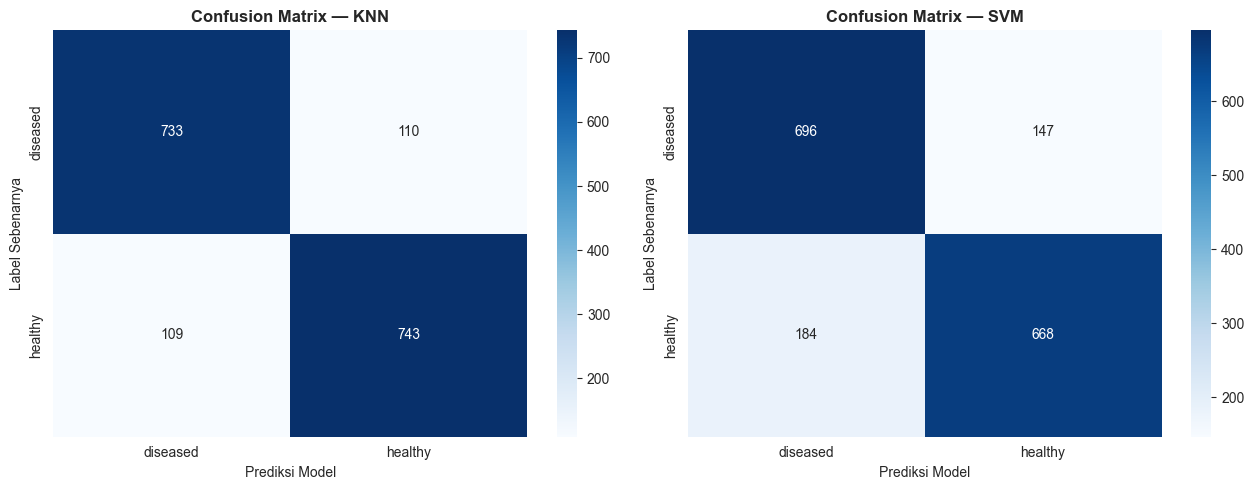

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, y_pred, judul in zip(axes, [y_pred_knn, y_pred_svm], ["KNN", "SVM"]):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
    ax.set_title(f"Confusion Matrix — {judul}", fontsize=12, fontweight="bold")
    ax.set_xlabel("Prediksi Model")
    ax.set_ylabel("Label Sebenarnya")

plt.tight_layout()
plt.show()

In [9]:
def cetak_metrik_lengkap(y_true, y_pred, nama_model):
    akurasi   = accuracy_score(y_true, y_pred)
    presisi   = precision_score(y_true, y_pred, average="weighted", zero_division=0)
    recall    = recall_score(y_true, y_pred, average="weighted", zero_division=0)
    f1        = f1_score(y_true, y_pred, average="weighted", zero_division=0)

    print(f"📊 METRIK EVALUASI — {nama_model}")
    print("=" * 40)
    print(f"   Akurasi   : {akurasi:.2%}")
    print(f"   Precision : {presisi:.2%}")
    print(f"   Recall    : {recall:.2%}")
    print(f"   F1-Score  : {f1:.2%}")
    print()
    print(classification_report(y_true, y_pred, target_names=label_encoder.classes_, zero_division=0))
    print("=" * 40)

cetak_metrik_lengkap(y_test, y_pred_knn, "KNN")
print()
cetak_metrik_lengkap(y_test, y_pred_svm, "SVM")

📊 METRIK EVALUASI — KNN
   Akurasi   : 87.08%
   Precision : 87.08%
   Recall    : 87.08%
   F1-Score  : 87.08%

              precision    recall  f1-score   support

    diseased       0.87      0.87      0.87       843
     healthy       0.87      0.87      0.87       852

    accuracy                           0.87      1695
   macro avg       0.87      0.87      0.87      1695
weighted avg       0.87      0.87      0.87      1695


📊 METRIK EVALUASI — SVM
   Akurasi   : 80.47%
   Precision : 80.53%
   Recall    : 80.47%
   F1-Score  : 80.46%

              precision    recall  f1-score   support

    diseased       0.79      0.83      0.81       843
     healthy       0.82      0.78      0.80       852

    accuracy                           0.80      1695
   macro avg       0.81      0.80      0.80      1695
weighted avg       0.81      0.80      0.80      1695



## **⚖️ 7. Perbandingan Performa Kedua Model**

  Model  Akurasi  Precision  Recall  F1-Score
0   KNN   0.8708     0.8708  0.8708    0.8708
1   SVM   0.8047     0.8053  0.8047    0.8046


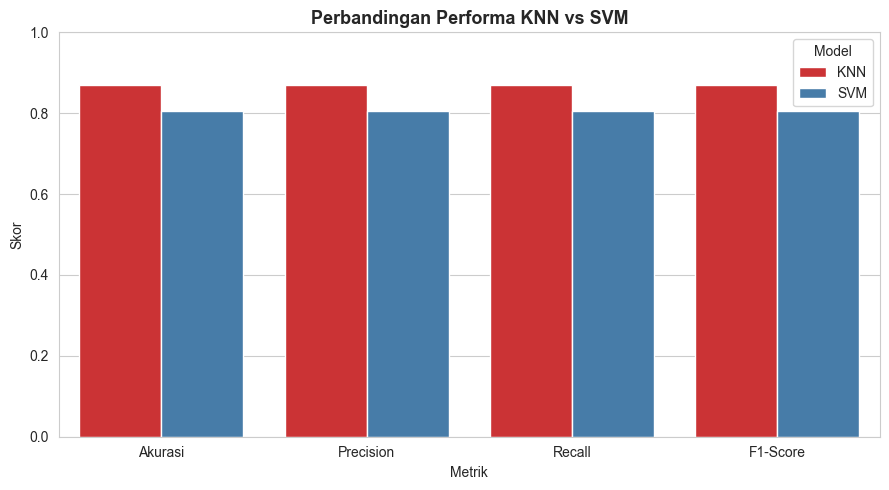

In [10]:
hasil_perbandingan = pd.DataFrame({
    "Model": ["KNN", "SVM"],
    "Akurasi": [accuracy_score(y_test, y_pred_knn), accuracy_score(y_test, y_pred_svm)],
    "Precision": [precision_score(y_test, y_pred_knn, average="weighted", zero_division=0),
                  precision_score(y_test, y_pred_svm, average="weighted", zero_division=0)],
    "Recall": [recall_score(y_test, y_pred_knn, average="weighted", zero_division=0),
               recall_score(y_test, y_pred_svm, average="weighted", zero_division=0)],
    "F1-Score": [f1_score(y_test, y_pred_knn, average="weighted", zero_division=0),
                 f1_score(y_test, y_pred_svm, average="weighted", zero_division=0)],
})

print(hasil_perbandingan.round(4))

hasil_melt = hasil_perbandingan.melt(id_vars="Model", var_name="Metrik", value_name="Skor")
plt.figure(figsize=(9, 5))
sns.barplot(data=hasil_melt, x="Metrik", y="Skor", hue="Model", palette="Set1")
plt.title("Perbandingan Performa KNN vs SVM", fontsize=13, fontweight="bold")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

## **🔍 8. Contoh Prediksi Salah (Error Analysis)**

Melihat langsung gambar mana saja yang **salah ditebak model** sangat berguna untuk memahami
keterbatasan model — apakah kesalahan terjadi karena fitur histogram warna memang tidak cukup
membedakan kasus tersebut.

In [11]:
hasil_prediksi = X_test.copy()
hasil_prediksi["label_asli"]  = label_encoder.inverse_transform(y_test)
hasil_prediksi["pred_svm"]    = label_encoder.inverse_transform(y_pred_svm)
hasil_prediksi["benar"]       = hasil_prediksi["label_asli"] == hasil_prediksi["pred_svm"]

salah_prediksi = hasil_prediksi[~hasil_prediksi["benar"]]
print(f"❌ Jumlah prediksi salah (model SVM): {len(salah_prediksi)} dari {len(hasil_prediksi)} data testing")
print(f"\nContoh kesalahan:")
print(salah_prediksi[["label_asli", "pred_svm"]].head(10))

❌ Jumlah prediksi salah (model SVM): 331 dari 1695 data testing

Contoh kesalahan:
     label_asli  pred_svm
3509    healthy  diseased
536    diseased   healthy
578    diseased   healthy
7321   diseased   healthy
7982   diseased   healthy
7780    healthy  diseased
4066    healthy  diseased
551    diseased   healthy
1129   diseased   healthy
4735   diseased   healthy


## **💬 9. Diskusi: Keterbatasan ML Klasik**

Meskipun KNN dan SVM bisa bekerja cukup baik pada kondisi pencahayaan normal, ada keterbatasan
mendasar dari pendekatan **Feature Extraction manual (histogram warna)** ini:

- 🌑 **Jika foto agak gelap atau pencahayaannya tidak merata** (seperti yang kita temukan saat
  EDA citra di Sesi 2), distribusi histogram warna ikut bergeser — padahal daunnya tetap sama,
  hanya kondisi fotonya yang berbeda. Model bisa salah menebak hanya karena perbedaan
  pencahayaan, bukan karena perbedaan kondisi daun yang sebenarnya.
- 🎯 **Histogram warna tidak menangkap bentuk/tekstur** — misal pola bercak penyakit yang
  spesifik bentuknya, hanya warnanya saja yang terekam.
- 🧩 **Fitur dipilih secara manual oleh manusia** — kita menebak bahwa histogram warna adalah
  fitur yang relevan, padahal mungkin ada pola visual lain yang lebih penting namun tidak
  terekam sama sekali oleh histogram.

💡 Inilah alasan kuat mengapa **Deep Learning** (terutama Convolutional Neural Network)
dikembangkan: ia bisa belajar fitur-fitur visual yang relevan **secara otomatis langsung dari
piksel mentah**, termasuk bentuk, tekstur, dan pola spasial — tanpa perlu manusia menebak dan
merancang fitur secara manual seperti yang kita lakukan di sesi ini.

## **🎓 Kesimpulan Sesi 3**

1. Melatih dua algoritma Supervised Learning klasik: **KNN** dan **SVM**
2. Memahami intuisi cara kerja masing-masing algoritma dalam menarik batas antar kelas
3. Mengevaluasi model menggunakan **Confusion Matrix** dan metrik lengkap (Precision, Recall,
   F1-Score) — bukan hanya akurasi
4. Melakukan **error analysis** dengan melihat langsung data yang salah ditebak
5. Mendiskusikan keterbatasan ML Klasik pada data citra, sebagai jembatan menuju materi
   **Deep Learning** di modul selanjutnya

💡 Di Sesi 4, kita akan beralih ke **Unsupervised Learning** sebagai sesi yang lebih santai
dan visual — bereksperimen dengan K-Means Clustering untuk efek "Pop-Art" pada foto.